In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [39]:
file_paths = {
    "2009-10": "Uganda - Food Prices (2009-10).csv",
    "2010-11": "Uganda - Food Prices (2010-11).csv",
    "2011-12": "Uganda - Food Prices (2011-12).csv",
    "2013-14": "Uganda - Food Prices (2013-14).csv",
    "2015-16": "Uganda - Food Prices (2015-16).csv",
    "2018-19": "Uganda - Food Prices (2018-19).csv"
}

dfs = {}
for year_label, path in file_paths.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df = df.rename(columns={'t': 'Year', 'j': 'Food Item', 'price': 'Price'})
        df = df[['Year', 'Food Item', 'Price']]
        df['Year_Label'] = year_label
        dfs[year_label] = df
    else:
        print(f"Missing file: {path}")


In [40]:
common_foods = set(dfs[list(dfs.keys())[0]]['Food Item'])
for df in dfs.values():
    common_foods &= set(df['Food Item'])
common_foods -= {'Butter'}
common_food_items_list = sorted(list(common_foods))
print(f"Number of common food items: {len(common_food_items_list)}")
pd.DataFrame({'Common Food Items': common_food_items_list})


Number of common food items: 51


,Common Food Items
0,Beans (dry)
1,Beans (fresh)
2,Beef
3,Beer
4,Bread
5,Cabbage (green)
6,Cassava (dry)
7,Cassava (fresh)
8,Chicken
9,Cigarettes


In [41]:
filtered_dfs = []
for year, df in dfs.items():
    filtered = df[df['Food Item'].isin(common_food_items_list)].copy()
    filtered['Year_Label'] = year
    filtered_dfs.append(filtered)

combined_df = pd.concat(filtered_dfs)
pivot_df = combined_df.pivot_table(index='Food Item', columns='Year_Label', values='Price', aggfunc='mean')
pivot_df = pivot_df.sort_index(axis=1)
pivot_df.head()


Year_Label,2009-10,2010-11,2011-12,2013-14,2015-16,2018-19
Food Item,,,,,,
Beans (dry),1331.442362,2436.693717,2274.512283,3253.104358,3144.405213,4482.576951
Beans (fresh),1014.560997,2250.762648,2541.115922,3644.495067,2943.303680,1560.473157
Beef,4268.951111,5285.926692,8442.272663,7169.731799,8296.331632,9662.182051
Beer,3064.300183,3528.946167,4423.353178,4848.263561,4812.331041,5375.397102
Bread,2059.848890,2833.881697,3873.489812,3391.457078,3442.656835,4390.610000


In [42]:
total_prices = pivot_df.sum()
inflation_total = total_prices.pct_change() * 100
total_prices_df = pd.DataFrame({
    'Total Price': total_prices,
    'Inflation Rate (%)': inflation_total
}).round(2)
total_prices_df


,Total Price,Inflation Rate (%)
Year_Label,,
2009-10,130070.35,NaN
2010-11,138845.22,6.75
2011-12,1082539.77,679.67
2013-14,263647.31,-75.65
2015-16,228741.85,-13.24
2018-19,293228.83,28.19


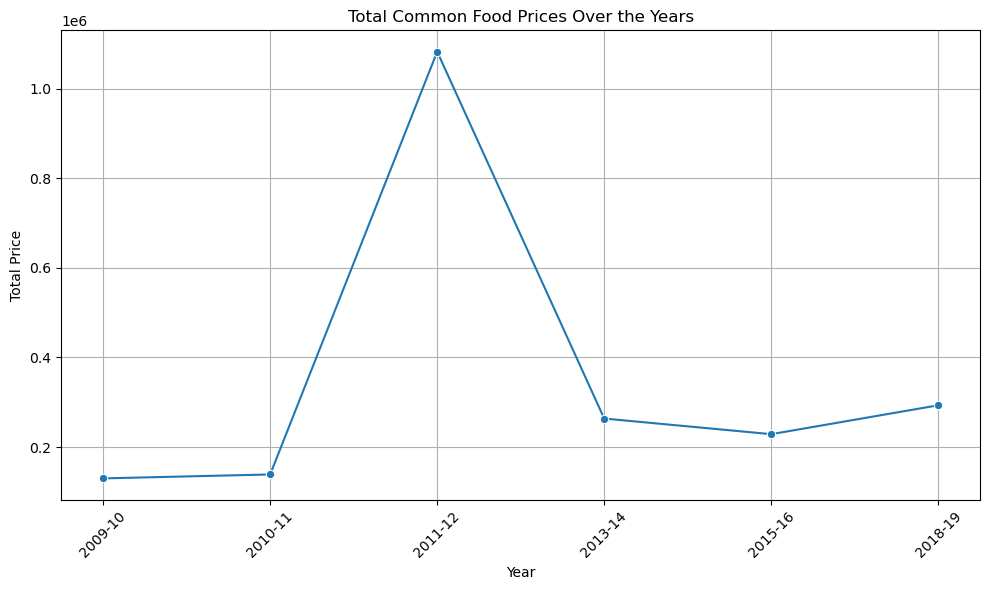

In [43]:
plt.figure(figsize=(10,6))
sns.lineplot(x=total_prices_df.index, y=total_prices_df['Total Price'], marker='o')
plt.title("Total Common Food Prices Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()




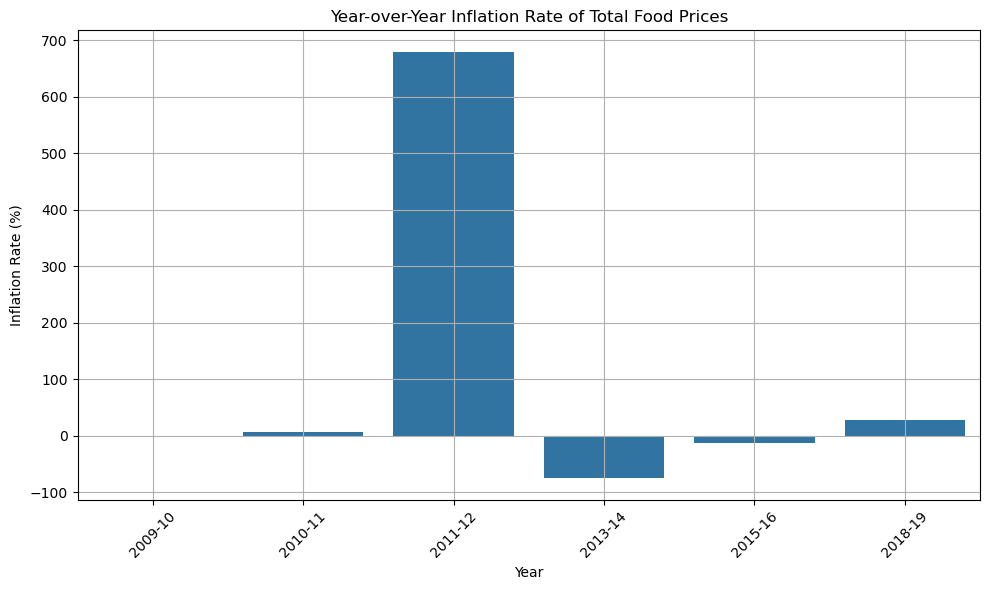

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(x=total_prices_df.index, y=total_prices_df['Inflation Rate (%)'])
plt.title("Year-over-Year Inflation Rate of Total Food Prices")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_188/3082959968.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_items = pivot_df.pct_change(axis=1) * 100


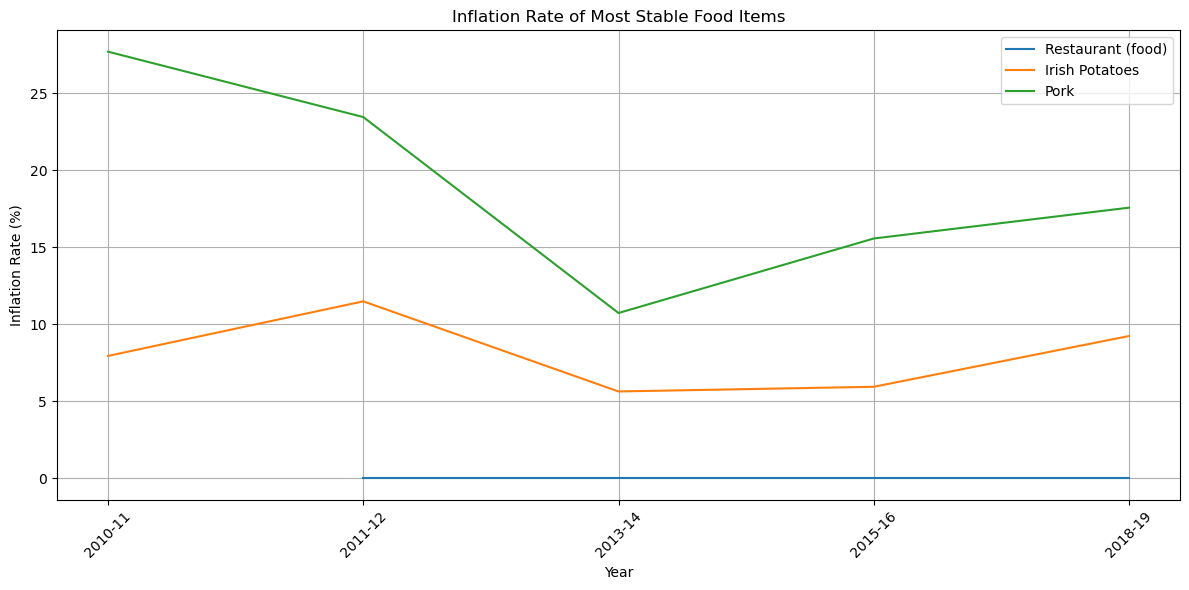

In [45]:
inflation_items = pivot_df.pct_change(axis=1) * 100
top_items = inflation_items.var(axis=1).nsmallest(3).index
plt.figure(figsize=(12, 6))
for item in top_items:
    sns.lineplot(data=inflation_items.loc[item], label=item)
plt.title("Inflation Rate of Most Stable Food Items")
plt.ylabel("Inflation Rate (%)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


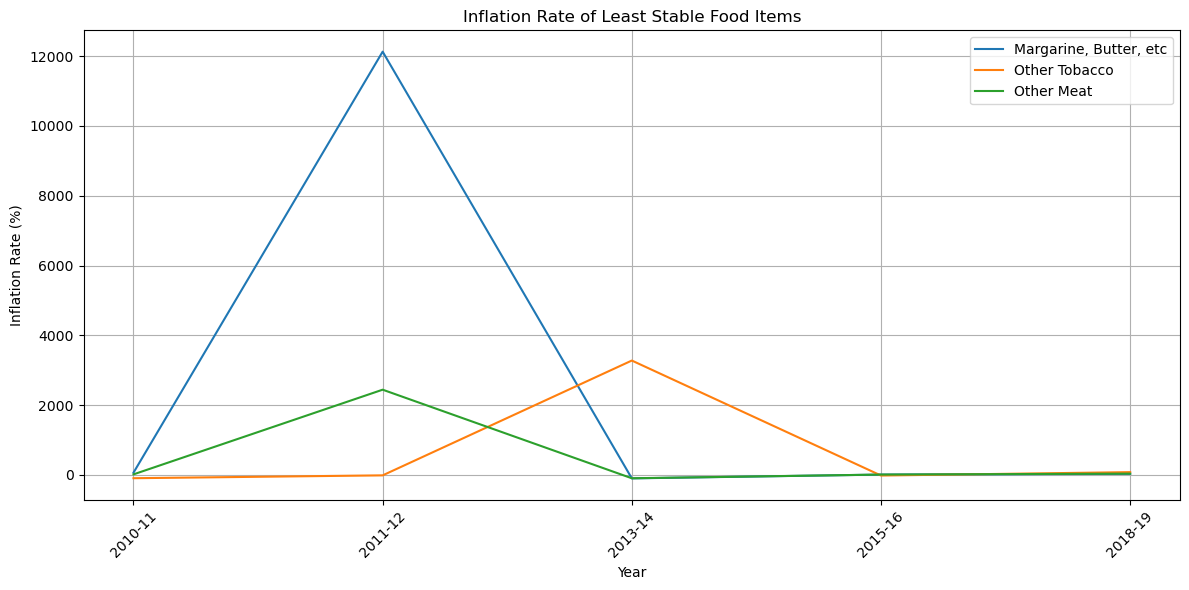

In [46]:
# Inflation Rate of Least Stable Food Items
least_stable_items = inflation_items.var(axis=1).nlargest(3).index
plt.figure(figsize=(12, 6))
for item in least_stable_items:
    sns.lineplot(data=inflation_items.loc[item], label=item)
plt.title("Inflation Rate of Least Stable Food Items")
plt.ylabel("Inflation Rate (%)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
# Total Inflation Without Least Stable Food Items
excluded_items = inflation_items.var(axis=1).nlargest(3).index
filtered_prices = pivot_df.drop(index=excluded_items)
filtered_total_prices = filtered_prices.sum()
filtered_inflation = filtered_total_prices.pct_change() * 100
filtered_total_prices_df = pd.DataFrame({
    'Total Price (Excl. Unstable)': filtered_total_prices,
    'Inflation Rate (%)': filtered_inflation
}).round(2)
filtered_total_prices_df


,Total Price (Excl. Unstable),Inflation Rate (%)
Year_Label,,
2009-10,114236.48,NaN
2010-11,126812.00,11.01
2011-12,156000.51,23.02
2013-14,238962.26,53.18
2015-16,205145.66,-14.15
2018-19,256747.33,25.15


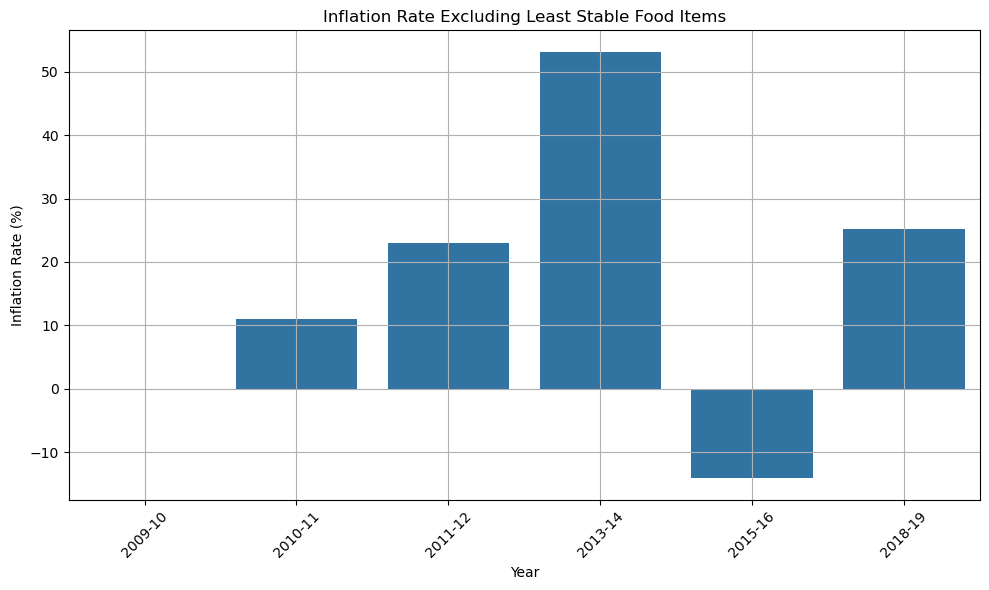

In [48]:
# Visualization of Total Inflation Without Least Stable Food Items
plt.figure(figsize=(10,6))
sns.barplot(x=filtered_total_prices_df.index, y=filtered_total_prices_df['Inflation Rate (%)'])
plt.title("Inflation Rate Excluding Least Stable Food Items")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


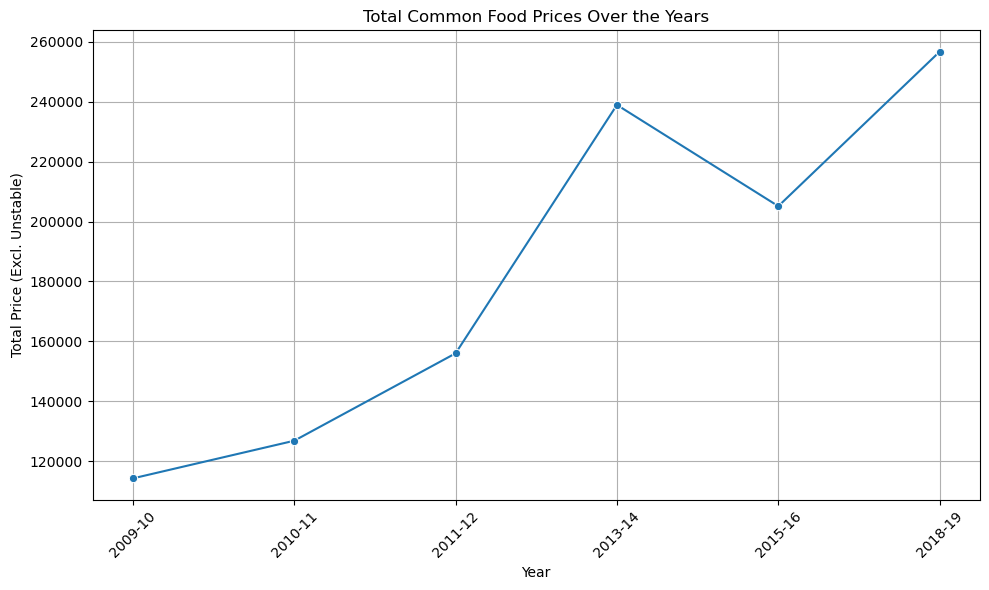

In [49]:

plt.figure(figsize=(10, 6))
sns.lineplot(x=filtered_total_prices_df.index, y=filtered_total_prices_df['Total Price (Excl. Unstable)'], marker='o')
plt.title("Total Common Food Prices Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Price (Excl. Unstable)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()